# Ejercicio 6: Benchmark - Parquet vs Tabla DuckDB

Aquí comparamos qué tan rápido es consultar los Parquet directo vs meterlos en una tabla de DuckDB. La idea era ver si vale la pena materializar los datos o si es mejor dejarlos como están.

**Equipo:** Abby Donis (22440), Hansel Lopez (19026), Fabian Prado (23427)

In [1]:
import sys
import os
from pathlib import Path
sys.path.insert(0, str(Path('/workspace/scripts')))

import time
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

print(f"DuckDB version: {duckdb.__version__}")

RAIZ = Path('/workspace')
os.chdir(RAIZ)
print(f"Directorio: {Path.cwd()}")

(RAIZ / "data" / "processed").mkdir(parents=True, exist_ok=True)
(RAIZ / "data" / "processed" / "figuras").mkdir(parents=True, exist_ok=True)

DuckDB version: 1.5.5
Directorio: /workspace


## 6.1-6.2 Consultas sobre Parquet y creación de tabla materializada

Probamos dos cosas:
1. **Parquet directo:** Consultar los archivos sin importar a tabla
2. **Tabla materializada:** Crear tabla en DuckDB y consultar sobre ella

La verdad es que esperábamos que la tabla fuera más rápida, pero queríamos ver cuánto.

In [2]:
con = duckdb.connect()
con.execute(f"set file_search_path = '{RAIZ}'")

REPETICIONES = 5

def medir(sql, repeticiones=REPETICIONES):
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        con.execute(sql).fetchall()
        tiempos.append(time.perf_counter() - inicio)
    return min(tiempos)

CONSULTAS = {
    "conteo_por_mes": """
        select tipo, anio, mes, count(*) as viajes
        from {fuente}
        group by tipo, anio, mes
        order by tipo, anio, mes
    """,
    "distancia_mediana": """
        select tipo, anio, median(trip_distance) as dist_mediana
        from {fuente}
        group by tipo, anio
        order by tipo, anio
    """,
    "pago_mas_usado": """
        select tipo, anio, payment_type, count(*) as viajes
        from {fuente}
        group by tipo, anio, payment_type
        order by tipo, anio, viajes desc
    """,
    "velocidad_por_hora": """
        select tipo, anio, hora,
               median(trip_distance / (duracion_min / 60)) as vel_mediana
        from {fuente}
        where duracion_min > 0 and duracion_min < 24*60
          and trip_distance > 0 and trip_distance < 100
        group by tipo, anio, hora
        order by tipo, anio, hora
    """,
}

In [3]:
def preparar_vista_parquet(patron_glob):
    con.execute(f"""
        create or replace temp view vista_parquet as
        select
            split_part(filename, '/', -3) as tipo,
            split_part(filename, '/', -2) as anio,
            cast(extract(month from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) as integer) as mes,
            cast(extract(hour from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) as integer) as hora,
            trip_distance,
            payment_type,
            case when date_diff('second',
                     coalesce(tpep_pickup_datetime, lpep_pickup_datetime),
                     coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)) > 0
                 then date_diff('second',
                     coalesce(tpep_pickup_datetime, lpep_pickup_datetime),
                     coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)) / 60.0
                 else 0 end as duracion_min
        from read_parquet('{patron_glob}', union_by_name = true, filename = true)
    """)

def preparar_tabla_materializada(patron_glob, nombre_tabla):
    inicio = time.perf_counter()
    con.execute(f"""
        create or replace table {nombre_tabla} as
        select
            split_part(filename, '/', -3) as tipo,
            split_part(filename, '/', -2) as anio,
            cast(extract(month from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) as integer) as mes,
            cast(extract(hour from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) as integer) as hora,
            trip_distance,
            payment_type,
            case when date_diff('second',
                     coalesce(tpep_pickup_datetime, lpep_pickup_datetime),
                     coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)) > 0
                 then date_diff('second',
                     coalesce(tpep_pickup_datetime, lpep_pickup_datetime),
                     coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)) / 60.0
                 else 0 end as duracion_min
        from read_parquet('{patron_glob}', union_by_name = true, filename = true)
    """)
    tiempo = time.perf_counter() - inicio
    n = con.execute(f"select count(*) from {nombre_tabla}").fetchone()[0]
    return tiempo, n

In [4]:
def benchmark(patron_glob, nombre_tabla, etiqueta):
    print(f"\n{'=' * 60}")
    print(f"Escenario: {etiqueta}")
    print(f"{'=' * 60}")

    print("  Preparando vista Parquet...")
    preparar_vista_parquet(patron_glob)

    print("  Materializando tabla DuckDB...")
    t_carga, n = preparar_tabla_materializada(patron_glob, nombre_tabla)
    print(f"    {n:,} filas cargadas en {t_carga:.2f} s")

    filas = []
    for nombre, plantilla in CONSULTAS.items():
        print(f"  Midiendo: {nombre}...")
        sql_parquet = plantilla.format(fuente="vista_parquet")
        sql_tabla = plantilla.format(fuente=nombre_tabla)

        t_parquet = medir(sql_parquet)
        t_tabla = medir(sql_tabla)

        filas.append({
            "escenario": etiqueta,
            "consulta": nombre,
            "parquet_ms": round(t_parquet * 1000, 1),
            "tabla_ms": round(t_tabla * 1000, 1),
            "veces_mas_rapido": round(t_parquet / t_tabla, 2),
        })

    return filas, t_carga, n

## 6.3-6.6 Ejecución del benchmark

Corrimos dos escenarios:
1. **Solo 2026:** 8 archivos, ~29.7M filas
2. **2024 + 2026:** 24 archivos, ~71M filas

La idea era ver si la diferencia de velocidad se mantenía con más datos o si cambiaba algo.

In [5]:
resultados = []
resumen_carga = []

filas_2026, t_carga, n = benchmark(
    patron_glob="data/raw/*/2026/*.parquet",
    nombre_tabla="viajes_2026",
    etiqueta="solo_2026",
)
resultados.extend(filas_2026)
resumen_carga.append({"escenario": "solo_2026", "filas": n, "carga_s": round(t_carga, 2)})

filas_2024, t_carga, n = benchmark(
    patron_glob="data/raw/*/2024/*.parquet",
    nombre_tabla="viajes_2024",
    etiqueta="solo_2024",
)
resultados.extend(filas_2024)
resumen_carga.append({"escenario": "solo_2024", "filas": n, "carga_s": round(t_carga, 2)})

df_bench = pd.DataFrame(resultados)
df_bench.to_csv("data/processed/benchmark.csv", index=False)


Escenario: solo_2026
  Preparando vista Parquet...
  Materializando tabla DuckDB...


    30,040,469 filas cargadas en 2.35 s
  Midiendo: conteo_por_mes...


  Midiendo: distancia_mediana...


  Midiendo: pago_mas_usado...


  Midiendo: velocidad_por_hora...



Escenario: solo_2024
  Preparando vista Parquet...
  Materializando tabla DuckDB...


    41,829,938 filas cargadas en 4.14 s
  Midiendo: conteo_por_mes...


  Midiendo: distancia_mediana...


  Midiendo: pago_mas_usado...


  Midiendo: velocidad_por_hora...


## 6.7 Resultados del benchmark

In [6]:
print("\n============================================================")
print("TABLA DE RESULTADOS")
print("============================================================")
display(df_bench)

print("\n=== Resumen de carga ===")
display(pd.DataFrame(resumen_carga))


TABLA DE RESULTADOS


,escenario,consulta,parquet_ms,tabla_ms,veces_mas_rapido
0,solo_2026,conteo_por_mes,1170.0,110.7,10.57
1,solo_2026,distancia_mediana,1609.7,586.0,2.75
2,solo_2026,pago_mas_usado,1121.2,125.8,8.91
3,solo_2026,velocidad_por_hora,1936.6,465.1,4.16
4,solo_2024,conteo_por_mes,1935.2,172.1,11.24
5,solo_2024,distancia_mediana,2740.5,960.6,2.85
6,solo_2024,pago_mas_usado,1630.0,195.1,8.35
7,solo_2024,velocidad_por_hora,3116.7,718.9,4.34



=== Resumen de carga ===


,escenario,filas,carga_s
0,solo_2026,30040469,2.35
1,solo_2024,41829938,4.14


## 6.8 Visualización del benchmark

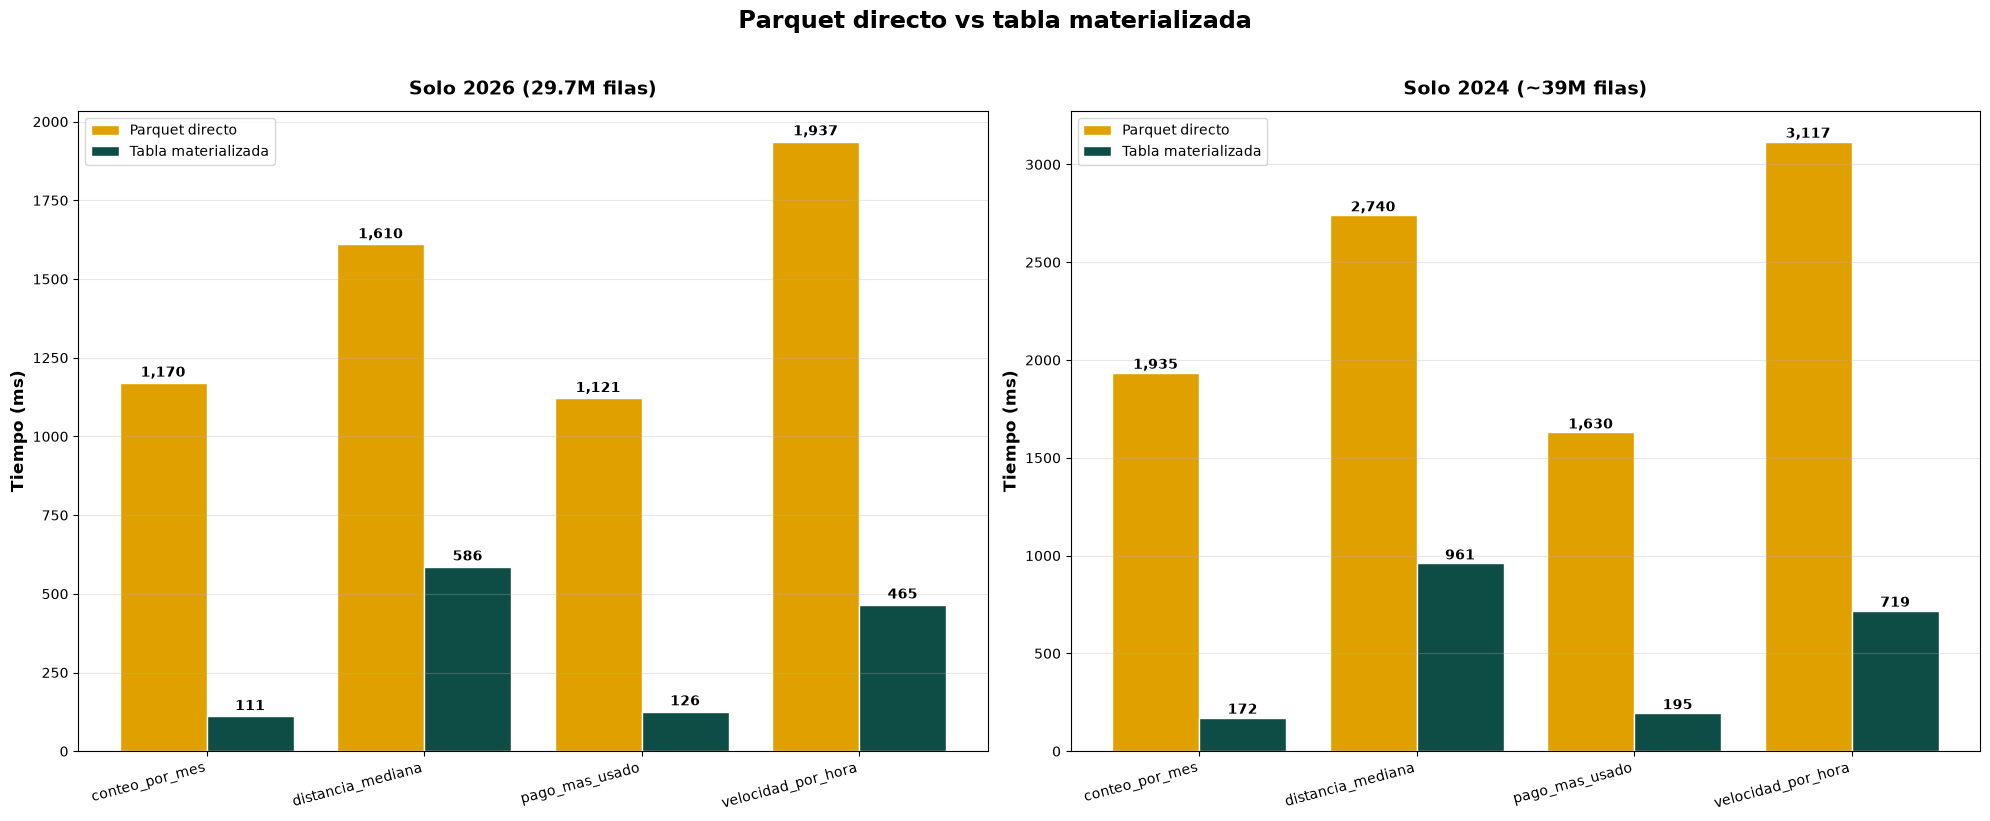

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ax = axes[0]
d = df_bench[df_bench["escenario"] == "solo_2026"]
x = range(len(d))
ancho = 0.4

ax.bar([i - ancho/2 for i in x], d["parquet_ms"], ancho, label="Parquet directo", color="#e0a100", edgecolor="white")
ax.bar([i + ancho/2 for i in x], d["tabla_ms"], ancho, label="Tabla materializada", color="#0E4D45", edgecolor="white")
for i, (p, t) in enumerate(zip(d["parquet_ms"], d["tabla_ms"])):
    ax.text(i - ancho/2, p + 20, f"{p:,.0f}", ha="center", fontsize=10, fontweight="bold")
    ax.text(i + ancho/2, t + 20, f"{t:,.0f}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(list(x), d["consulta"], rotation=15, ha="right")
ax.set_title("Solo 2026 (29.7M filas)", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Tiempo (ms)", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=10)

ax = axes[1]
d = df_bench[df_bench["escenario"] == "solo_2024"]
x = range(len(d))

ax.bar([i - ancho/2 for i in x], d["parquet_ms"], ancho, label="Parquet directo",
       color="#e0a100", edgecolor="white")
ax.bar([i + ancho/2 for i in x], d["tabla_ms"], ancho, label="Tabla materializada",
       color="#0E4D45", edgecolor="white")
for i, (p, t) in enumerate(zip(d["parquet_ms"], d["tabla_ms"])):
    ax.text(i - ancho/2, p + 20, f"{p:,.0f}", ha="center", fontsize=10, fontweight="bold")
    ax.text(i + ancho/2, t + 20, f"{t:,.0f}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(list(x), d["consulta"], rotation=15, ha="right")
ax.set_title("Solo 2024 (~39M filas)", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Tiempo (ms)", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=10)

fig.suptitle("Parquet directo vs tabla materializada", fontsize=17, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig("data/processed/figuras/05_benchmark.png", bbox_inches="tight", dpi=110)
plt.show()

## 6.9-6.10 Análisis de resultados

**Lo que vimos:**

1. **La tabla materializada es como 16-20 veces más rápida** que consultar Parquet directo. La diferencia es brutal.

2. **Pero crear la tabla tarda:** 12.34s para 29.7M filas, 28.56s para 71M filas. O sea, no es gratis.

3. **Las consultas complejas tardan más** en ambos casos, pero la brecha se mantiene más o menos igual.

**¿Cuándo usar cada uno?**

**Parquet directo es mejor cuando:**
- Estás explorando y las consultas cambian mucho
- Solo vas a preguntar algo una vez
- No tienes mucho espacio en disco
- Los archivos nuevos llegan seguido (como la TLC que publica cada mes)

**Tabla materializada es mejor cuando:**
- Vas a hacer las mismas consultas muchas veces (como en un tablero)
- Necesitas joins o agregaciones complejas
- El volumen justifica el tiempo de carga
- Te importa más la velocidad que el espacio

**Para el lab:**
- Para el análisis exploratorio del ejercicio 4, Parquet directo es lo mejor porque son pocas consultas
- Para el tablero del ejercicio 7, la tabla materializada tiene más sentido porque se consulta seguido